In [2]:
from pyuvdata import UVData, UVBeam, utils as uvutils
import numpy as np
import hdf5plugin
import copy
import uvtools as uvt
import matplotlib.pyplot as plt
import hera_cal as hc
# import healvis
from scipy.signal import windows

import astropy.io.fits as fits
import pandas as pd
import h5py
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
import glob
import os
from scipy import stats
import hera_pspec as hp
import astropy
from astropy.time import Time
from astropy.coordinates import get_sun
import astropy.units as u

In [3]:
import glob
import re
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"
path_data2="/net/sinatra/vault2/ntsikelelo/Data_H6C/"
def numerical_sort(value):
    # Find all digit groups and convert them to integers
    numbers = re.findall(r'\d+', value)
    return list(map(int, numbers)) if numbers else [0]

uvh5name = sorted(glob.glob(path_data2+"*sum.uvh5"), key=numerical_sort)
# files_diff=files = sorted(glob.glob(path_data+"*diff.uvh5"), key=numerical_sort)

In [4]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read(Model_complete_file, read_data=False)  
pol=uvd1.polarization_array[0]
uvd1.read(Model_complete_file, polarizations=pol) 
antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))

#make redundant groups model        
reds = hc.redcal.get_pos_reds(antpos_d, include_autos=True)

In [5]:

filter_name="Main_lobe_20_mHz"
filter_name_2="Notch_filter_40_mHz_interpolated"
filter_name_3="Notch_filter_80_mHz"
filter_name_4="Main_lobe_baseline_dependent"
filter_name_5="Notch_filter_20_mHz"
lst="0h"
spw="low"

In [6]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read(Model_complete_file, read_data=False)  

antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))
times_total=[]
lsts_total=[]
n=0
#get metadata 
for i in range (250):
   
    # print (lsts_center, 4*i+n)
    Model_complete_file =uvh5name[4*i+n]
    uvd1 = UVData()
    uvd1.read(Model_complete_file, read_data=False)  
    times=np.unique(uvd1.time_array)
    times_total.append(times[0])
    lsts=np.rad2deg(np.unique(uvd1.lst_array))*(24/360)
    lsts_total.append(lsts[0])

In [7]:

uvd1 = UVData()
uvd1.read("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Full_LST_gleam_model_final_"+lst+"_"+spw+".uvh5", read_data=False)
freqs = uvd1.freq_array*1e-6

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


Text(0, 0.5, 'LST [hours]')

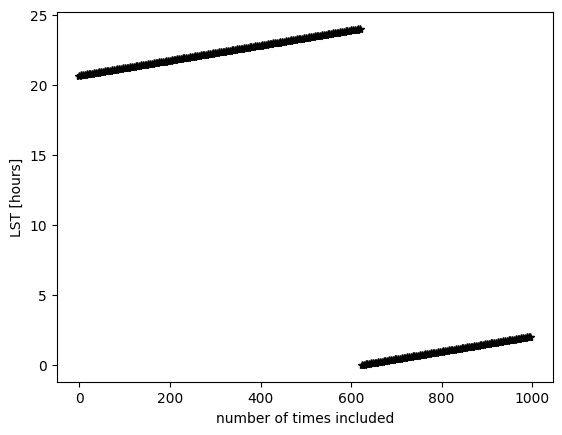

In [89]:

plt.plot(4*np.arange(250), lsts_total, 'k*')
plt.xlabel("number of times included")
plt.ylabel("LST [hours]")

In [90]:

def JytomK(Jy, f0=163e6):
    """Convert Jansky to mK

    Args:
        Jy (float): brightness in Jy
        f0 (float): frequency in Hz

    Returns:
        float: brightness temperature in mK
    """

    # wavelength in m
    c=3.0e8
    lam = c / f0

    # flux density in W/m^2/Hz
    S = Jy * 1e-26
    kb=1.38064852e-23
    # temperature in K
    T = S * lam ** 2 / (2 * kb)

    # rettourn temperature in mK
    return T * 1e3

def power_spectrum(V, baseline, f1, df, delays):
    window = windows.blackmanharris(delays.shape[0])
    comso=hp.conversions.Cosmo_Conversions(Om_l=0.7,H0=70,Om_c=0.3)
    c=3e8
   
    f0=1420.0e6
    lambda_0=c/f0
    lambda_1=c/f1

    z=(lambda_1-lambda_0)/lambda_0
    factor=comso.bl_to_kperp(z=z)
    theta=(lambda_1/baseline)
    Dc=comso.dRperp_dtheta(z)*theta
    Beff=np.sum(window*df)
    Delta_D=comso.dRpara_df(z)*Beff
    k_par=comso.tau_to_kpara(z=z)*delays*1e-9
    k_per=factor*baseline
    theta_d=np.rad2deg(theta)
    Ae=theta_d**2
    

    steradian=(180.0/np.pi)**2 #degrees per steradian
    Omega= Ae/steradian
    V_mk=JytomK(Jy=V,f0=f1)
    constant=((Dc**2*Delta_D)/(Beff))*(1/(Omega*Beff))
    P=V_mk**2*constant*df**2
    
    print(" at redshift "+str(z))
    return k_par,np.array(P)
def vis_perform_delay_trans(freqs=freqs, data=""):

    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=windows.blackmanharris(len(freqs))
    
    
    
    print(len(data))
    data_full_bls=[]
    for t in range(len(data)):
       
        for bls in range (len(data[t])):
            data_time_no_nans=data[t][bls][~np.isnan(data[t][bls])]
            freq_no_nans=freqs[~np.isnan(data[t][bls])]
            if len(freq_no_nans)>150:
                coeffs = np.polyfit(freq_no_nans, data_time_no_nans, 6)
                poly = np.poly1d(coeffs)
                x_fit=freqs
                y_fit=poly(x_fit)
                data_fitted=[]
                for i in range (data[t][bls].shape[0]):
                    if np.isnan(data[t][bls][i]):
                        data_fitted.append(poly(x_fit[i]))
                    else:
                        data_fitted.append(data[t][bls][i])
                data_fitted=np.array(data_fitted) 
               
                data_full_bls.append(data_fitted)
                
    data_full_bls=np.array(data_full_bls)
    print(data_full_bls.shape)
    cross_power=[]
    for i in range (data_full_bls.shape[0]-1):
        
               
                g0_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i]))
                g1_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i+1]))
                cross_power.append(g0_delay*np.conjugate(g1_delay))

                
    cross_power=np.array(cross_power)
    kpar, power_spectrum_cross_power=power_spectrum(V=cross_power, baseline=14.5, f1=62.5e6, df=122e3, delays=tau)
    return data_full_bls, power_spectrum_cross_power, kpar

In [91]:
hd = io.HERAData(uvh5name[0])
# antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
# antpos_d = dict(zip(ants, antpos))
reds = redcal.get_reds(hd.data_antpos, pols=['nn'], pol_mode='1pol')

OSError: Cannot find file /net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.25297.sum.uvh5 in /home/ntsikelelo/Projects/Fringe_rate_filtering

In [ ]:
N=120

def filter_data(cal_data):

    index_flag=np.where((freqs>=70.2 ) & (freqs<=70.3) )
    
    cal_data_filtered=[]
    for bl in cal_data:
        blvec = (antpos[np.where(ants==bl[0])] - antpos[np.where(ants==bl[1])])
        
        if np.abs(np.linalg.norm(blvec)-14)<2:

            
            cal_data_flagged=np.array(cal_data[bl][0,:])
            cal_data_flagged[index_flag]=np.nan*(np.ones(cal_data_flagged[index_flag].shape))
            cal_data_filtered.append(cal_data_flagged)
    
    return cal_data_filtered
    
def extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_", lst="0h", spw="low", uvh5name=uvh5name, N=N):

    k=0 
    cal_all_data=[]
    for x in range(N):
            n=k+x  
            i=4*n
    
    
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", allow_pickle=True).item()
            cal_all_data.append(filter_data(cal_data))
    
       
            i2=4*n+1

            cal_data = np.load(file_name+uvh5name[i2][43:69]+"_1h_"+spw+".npy", allow_pickle=True).item()
    
            cal_all_data.append(filter_data(cal_data))
            i3=4*n+2
            if x!=65:
                
               
                cal_data = np.load(file_name+uvh5name[i3][43:69]+"_2h_"+spw+".npy", allow_pickle=True).item()
            
                cal_all_data.append(filter_data(cal_data)) 
            
            i4=4*n+3
           
            cal_data = np.load(file_name+uvh5name[i4][43:69]+"_3h_"+spw+".npy", allow_pickle=True).item()
        
            cal_all_data.append(filter_data(cal_data))       

  
    return cal_all_data        

In [ ]:
def extrac_cal_data_post_RFI_flag(filter_name=filter_name_2, mode="gleam", lst="0h", spw="low", N=N):

    k=0
    cal_all_data=[]
    for ti in range(N): 
        cal_data = np.load(path_data+"red_flagged_"+mode+"_"+filter_name+"_0h_"+spw+"_"+str(ti)+".npy")
        cal_all_data.append(cal_data)    

        cal_data2 = np.load(path_data+"red_flagged_"+mode+"_"+filter_name+"_1h_"+spw+"_"+str(ti)+".npy")
        cal_all_data.append(cal_data2)  
        if ti!=65:
            cal_data3 = np.load(path_data+"red_flagged_"+mode+"_"+filter_name+"_2h_"+spw+"_"+str(ti)+".npy")
            cal_all_data.append(cal_data3)  

        cal_data4 = np.load(path_data+"red_flagged_"+mode+"_"+filter_name+"_3h_"+spw+"_"+str(ti)+".npy")
        cal_all_data.append(cal_data4)  

    return cal_all_data



In [ ]:
cal_data_full=extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_",lst=lst , spw=spw,  uvh5name=uvh5name, N=N)
cal_data_gleam=extrac_cal_data(file_name=path_data+"abs_calibrated_data_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

# cal_data_gleam_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
# cal_data_full_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_full_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

cal_data_gleam_filter_notch=extrac_cal_data_post_RFI_flag(filter_name=filter_name_2, mode="gleam", lst="0h", spw="low", N=N)
cal_data_full_filter_notch=extrac_cal_data_post_RFI_flag(filter_name=filter_name_2, mode="full", lst="0h", spw="low", N=N)


# cal_data_gleam_filter_notch_80_mHz=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_3+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

# cal_data_gleam_filter_main_lobe_baseline_dependent=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_4+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
# cal_data_gleam_filter_notch_20_mHz=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_5+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

In [ ]:
#70 to 95
# # n=0
c, p, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam)
# c2, p2, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_filter)
# c3, p3, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter)
c4, p4, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full)

c5, p5, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch)
c6, p6, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_filter_notch)

# c7, p7, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch_80_mHz)

# c8, p8, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_main_lobe_baseline_dependent)

# c9, p9, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch_20_mHz)

In [ ]:

def take_mean_and_fold(tau, p):
    p_ave_in= np.mean(p, axis=0)
    # p_ave=p_ave_in/np.max(np.abs(p_ave_in))
    return p_ave_in[103:205]
    

In [ ]:
noise_level.shape


In [ ]:
p_ave= take_mean_and_fold(tau, p)
p_ave4= take_mean_and_fold(tau, p4)
p_ave5= take_mean_and_fold(tau, p5)
p_ave6= take_mean_and_fold(tau, p6)
constant=np.max(np.abs(p_ave4))
noise_level=2*np.std(np.imag(p4),axis=0)[103:205]
plt.plot(tau[tau>0], constant*np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch gleam")
plt.plot(tau[tau>0],constant*np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.semilogy(tau[tau>0],constant*np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
plt.semilogy(tau[tau>0], constant*np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
plt.semilogy(tau[tau>0][20:103],noise_level[20:103] ,'--k', label="noise")
plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
# plt.xlim([0,0.6])
plt.legend()
plt.savefig("paper_figures/power_spectra_notch.pdf")

In [47]:
p_ave= take_mean_and_fold(tau, p)
# p_ave2= take_mean_and_fold(tau, p2)
p_ave3= take_mean_and_fold(tau, p3)
# p_ave4= take_mean_and_fold(tau, p4)
p_ave5= take_mean_and_fold(tau, p5)
# p_ave6= take_mean_and_fold(tau, p6)
# p_ave7= take_mean_and_fold(tau, p7)
# p_ave8= take_mean_and_fold(tau, p8)
# p_ave9= take_mean_and_fold(tau, p9)
# plt.semilogy(tau[tau>=0], np.abs(p_test),'g', label="notch gleam")
# plt.plot(tau[tau>0], np.abs(p_ave9)/np.max(np.abs(p_ave9)),'m', label="notch 20 mHz")
# # plt.plot(tau[tau>0], np.abs(p_ave8)/np.max(np.abs(p_ave8)),'r', label="Main lobe baseline dependent")
# plt.plot(tau[tau>0], np.abs(p_ave7)/np.max(np.abs(p_ave7)),'b', label="notch 80 mHz")
plt.plot(tau[tau>0], np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch 40 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe 40 mHz")
# plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
plt.xlim([0,0.6])
plt.legend()
# plt.savefig("paper_figures/power_spectra_notch.pdf")

NameError: name 'p3' is not defined

In [18]:
p_ave= take_mean_and_fold(tau, p)
# p_ave2= take_mean_and_fold(tau, p2)
# p_ave3= take_mean_and_fold(tau, p3)
# p_ave4= take_mean_and_fold(tau, p4)
p_ave5= take_mean_and_fold(tau, p5)
# p_ave6= take_mean_and_fold(tau, p6)
p_ave7= take_mean_and_fold(tau, p7)
# p_ave8= take_mean_and_fold(tau, p8)
p_ave9= take_mean_and_fold(tau, p9)
# plt.semilogy(tau[tau>=0], np.abs(p_test),'g', label="notch gleam")
# plt.plot(tau[tau>0], np.abs(p_ave9)/np.max(np.abs(p_ave9)),'m', label="notch 20 mHz")
plt.plot(tau[tau>0], np.abs(p_ave8)/np.max(np.abs(p_ave8)),'r', label="Main lobe baseline dependent")
# plt.plot(tau[tau>0], np.abs(p_ave7)/np.max(np.abs(p_ave7)),'b', label="notch 80 mHz")
plt.plot(tau[tau>0], np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch 40 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe 40 mHz")
# plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
plt.xlim([0,0.4])
plt.legend()
plt.savefig("paper_figures/power_spectra_two_filters_notch.pdf")

NameError: name 'p7' is not defined

In [ ]:
p_ave= take_mean_and_fold(tau, p)
# p_ave2= take_mean_and_fold(tau, p2)
# p_ave3= take_mean_and_fold(tau, p3)
# p_ave4= take_mean_and_fold(tau, p4)
p_ave5= take_mean_and_fold(tau, p5)
# p_ave6= take_mean_and_fold(tau, p6)
p_ave7= take_mean_and_fold(tau, p7)
# p_ave8= take_mean_and_fold(tau, p8)
p_ave9= take_mean_and_fold(tau, p9)
# plt.semilogy(tau[tau>=0], np.abs(p_test),'g', label="notch gleam")
plt.plot(tau[tau>0], np.abs(p_ave9)/np.max(np.abs(p_ave9)),'m', label="notch 20 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave8)/np.max(np.abs(p_ave8)),'r', label="Main lobe baseline dependent")
plt.plot(tau[tau>0], np.abs(p_ave7)/np.max(np.abs(p_ave7)),'b', label="notch 80 mHz")
plt.plot(tau[tau>0], np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch 40 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe 40 mHz")
# plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
plt.xlim([0,0.6])
plt.legend()
plt.savefig("paper_figures/power_spectra_two_filters_notch_2.pdf")

In [1]:
## Interpolate vs no interpolate

In [735]:
def extrac_cal_data_interpolate(file_name=path_data+"abs_calibrated_data_full_", lst="0h", spw="low", uvh5name=uvh5name, N=N):

    k=0 
    cal_all_data=[]
    cal_all_data_no_inter=[]
    for x in range(N):
        
            n=k+x  
            i=4*n
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_0h_"+spw+".npy", allow_pickle=True).item()
    
            cal_all_data.append(filter_data(cal_data))
    
            i3=4*n+2
            cal_data = np.load(file_name+uvh5name[i3][43:69]+"_2h_"+spw+"_no_interpolation.npy", allow_pickle=True).item()
            cal_all_data_no_inter.append(filter_data(cal_data))
    
       
            
           
            
           
            # cal_data = np.load(file_name+uvh5name[i3][43:69]+"_2h_"+spw+".npy", allow_pickle=True).item()
        
            # cal_all_data.append(filter_data(cal_data))             

  
    return cal_all_data, cal_all_data_no_inter       


In [738]:
N=200
cal_all_data, cal_all_data_no_inter =extrac_cal_data_interpolate(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_",lst=lst , spw=spw,  uvh5name=uvh5name, N=N)

In [739]:
c, p, tau=vis_perform_delay_trans(freqs=freqs, data=cal_all_data)
c2_no_inter, p2_no_inter, tau=vis_perform_delay_trans(freqs=freqs, data=cal_all_data_no_inter)


200
(18403, 205)
 at redshift 21.72
200
(18384, 205)
 at redshift 21.72


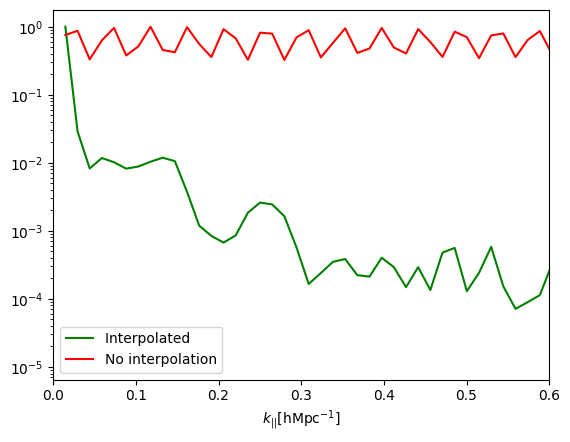

In [740]:
p_ave= take_mean_and_fold(tau, p)
p_ave2= take_mean_and_fold(tau,  p2_no_inter)
plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'g', label="Interpolated ")
plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'r', label="No interpolation")
# plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe 40 mHz")
# plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
plt.xlim([0,0.6])
plt.legend()
plt.savefig("paper_figures/power_spectra_two_no_interpolation_vs_interpolation.pdf")

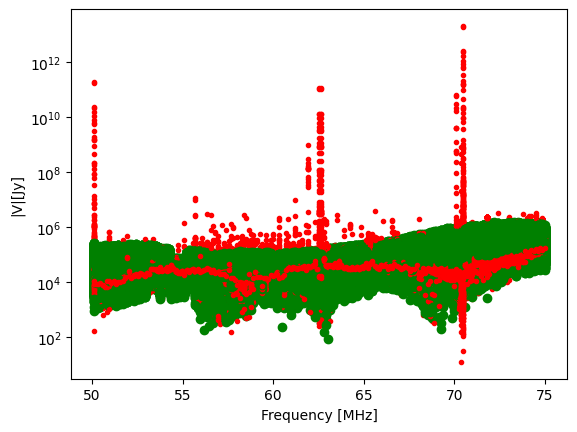

In [741]:
plt.figure()
for i in range (1200):

    plt.semilogy(freqs,np.abs(c[i,:]) ,'go', label="Interpolated ")
    plt.semilogy(freqs, np.abs(c2_no_inter[i,:]),'r.', label="No interpolation")
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("|V|[Jy]")
plt.savefig("paper_figures/frequency_spectra_two_no_interpolation_vs_interpolation.pdf")

In [616]:
def filter_data_reds(cal_data):
 

    reds_14_m=[]
    for k in reds[0]:
        reds_14_m.append(k)
    cal_data_filtered=[]

    # print(reds_14_m)
    index_flag=np.where((freqs>=70.2 ) & (freqs<=70.3) )
    for  bls in cal_data:
        if bls in reds_14_m:       
        
            cal_data_flagged=np.array(cal_data[bls][0,:])
            cal_data_flagged[index_flag]=np.nan*(np.ones(cal_data_flagged[index_flag].shape))
            cal_data_filtered.append(cal_data_flagged)
    
    return cal_data_filtered
    
def extrac_cal_data_reds(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, N=N):

    k=0  
    cal_all_data=[]
    for x in range(N):
        n=k+x 
        i=4*n
        cal_data = np.load(file_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", allow_pickle=True).item()
        cal_all_data.append(filter_data_reds(cal_data))  
                    
        i2=4*n+1

        cal_data = np.load(file_name+uvh5name[i2][43:69]+"_1h_"+spw+".npy", allow_pickle=True).item()

        cal_all_data.append(filter_data_reds(cal_data))

        # i3=4*n+2
    
        # cal_data = np.load(file_name+uvh5name[i3][43:69]+"_2h_"+spw+".npy", allow_pickle=True).item()
    
        # cal_all_data.append(filter_data_reds(cal_data))  

        # i4=4*n+3
    
        # cal_data = np.load(file_name+uvh5name[i4][43:69]+"_3h_"+spw+".npy", allow_pickle=True).item()
    
        # cal_all_data.append(filter_data_reds(cal_data))  

        

        return cal_all_data   

In [617]:

def plot_redundant_abs(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, label="gleam", colour='k'):

    cal_data=extrac_cal_data_reds(file_name=file_name, uvh5name=uvh5name, N=N)
    print(len(cal_data[0]))
    data=[]
    for n in range (len(cal_data[0])):
        # plt.semilogy(freqs,np.abs(cal_data[0][n]),'*')
        data.append(np.abs(cal_data[0][n]))
    plt.semilogy(freqs, np.mean(data, axis=0), colour, label=label)
    g_f=[]
    g=np.mean(data, axis=0)
    for i in range (205):
        if not np.isnan(g[i]):
            g_f.append(g[i])
    print(np.mean(g_f),label)
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("|V|[Jy]")

In [618]:
def plot_redundant_abs_individual(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, label="gleam", colour='k'):

    cal_data=extrac_cal_data_reds(file_name=file_name, uvh5name=uvh5name, N=N)
    print(len(cal_data[0]))
    data=[]
    for n in range (len(cal_data[0])):
        # plt.semilogy(freqs,np.abs(cal_data[0][n]),'*')
        data.append(np.abs(cal_data[0][n]))
        plt.semilogy(freqs, np.abs(cal_data[0][n]), colour, label=label)
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("|V|[Jy]")

26
50089.453687640496 gleam
26
84693.35368527677 full
26
15134.386363698077 gleam notch filter
26
60016.262582946205 Mainlobe filter


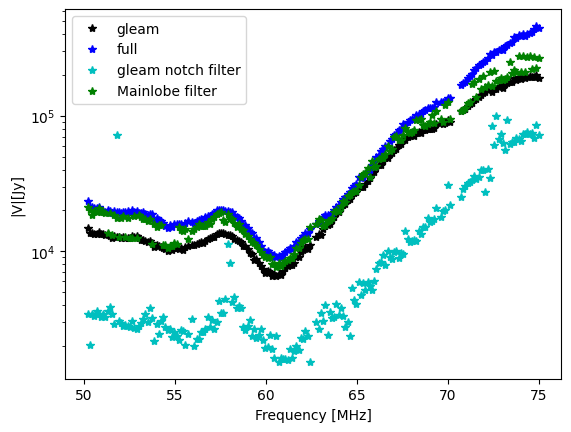

In [619]:
plt.figure()
plot_redundant_abs(file_name=path_data+"abs_calibrated_data_gleam_", uvh5name=uvh5name, label="gleam", colour='k*')
plot_redundant_abs(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, label="full", colour='b*')
plot_redundant_abs(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_", label="gleam notch filter", uvh5name=uvh5name, colour='c*')
plot_redundant_abs(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_", label="Mainlobe filter", uvh5name=uvh5name, colour='g*')
plt.legend()
plt.savefig("paper_figures/visibility_amp_notch_filter.pdf")


26


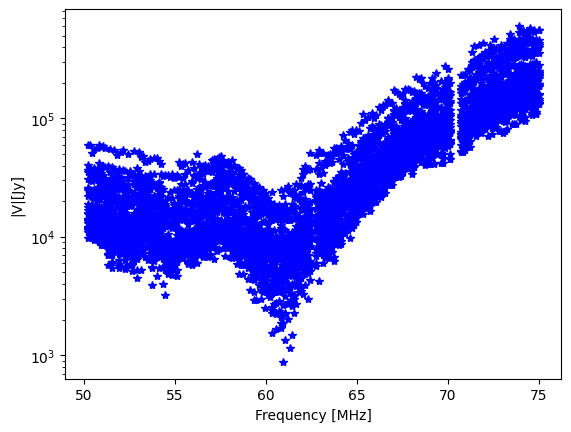

In [620]:
plt.figure()
#plot_redundant_abs_individual(file_name=path_data+"abs_calibrated_data_gleam_", uvh5name=uvh5name, label="gleam", colour='k*')
plot_redundant_abs_individual(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_", uvh5name=uvh5name, label="full", colour='b*')
#plot_redundant_abs_individual(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_", label="gleam notch filter", uvh5name=uvh5name, colour='c*')
# plt.legend()
# plt.savefig("paper_figures/visibility_amp_notch_filter.pdf")


26
26
26


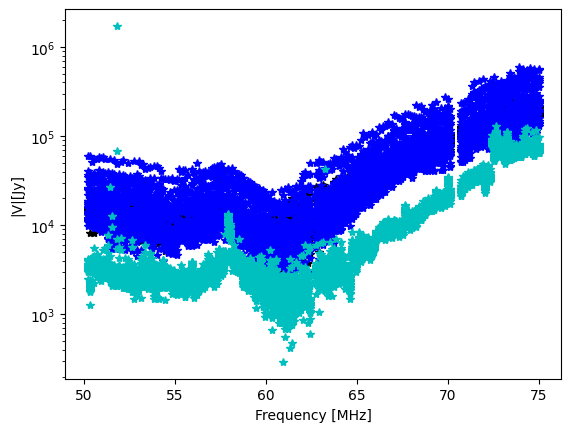

In [621]:
plt.figure()
plot_redundant_abs_individual(file_name=path_data+"abs_calibrated_data_gleam_", uvh5name=uvh5name, label="gleam", colour='k*')
plot_redundant_abs_individual(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_", uvh5name=uvh5name, label="full", colour='b*')
plot_redundant_abs_individual(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_", label="gleam notch filter", uvh5name=uvh5name, colour='c*')
# plt.legend()
# plt.savefig("paper_figures/visibility_amp_notch_filter.pdf")
# plt.xlim([55,60])

## Gain analysis

In [704]:
N=120
def extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    k=0
    for x in range (N):
        n=k+x
        i=4*n
        g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy",allow_pickle=True).item()
        gain_temp=[]
        for ant in g1:
            for t in range (1):
                gain_temp.append(g1[ant][t,:])
        gain_temp=np.array(gain_temp)
        gain_ave=np.mean(np.abs(gain_temp), axis=0)
        gains_gleam.append(gain_ave)

    for x in range (N):
        n=k+x
        i=4*n+1
        g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_1h_"+spw+".npy",allow_pickle=True).item()
        gain_temp=[]
        for ant in g1:
            for t in range (1):
                gain_temp.append(g1[ant][t,:])
        gain_temp=np.array(gain_temp)
        gain_ave=np.mean(np.abs(gain_temp), axis=0)
        gains_gleam.append(gain_ave)    
    

    for x in range (N):
        n=k+x
        i=4*n+2
        if  x!=64 :   
            g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_2h_"+spw+".npy",allow_pickle=True).item()
            gain_temp=[]
            for ant in g1:
                for t in range (1):
                    gain_temp.append(g1[ant][t,:])
            gain_temp=np.array(gain_temp)
            gain_ave=np.mean(np.abs(gain_temp), axis=0)
            gains_gleam.append(gain_ave) 

    for x in range (N):
        n=k+x  
       
        i=4*n+3
        g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_3h_"+spw+".npy",allow_pickle=True).item()
        gain_temp=[]
        for ant in g1:
            for t in range (1):
                gain_temp.append(g1[ant][t,:])
        gain_temp=np.array(gain_temp)
        gain_ave=np.mean(np.abs(gain_temp), axis=0)
        gains_gleam.append(gain_ave)    


    return np.array(gains_gleam)

gains_gleam_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_gleam_filter_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_2+"_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_full_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full_filter_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_2+"_full_flagged_abscal", N=N,uvh5name=uvh5name)

gains_full_filter_notch_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_2+"_full_flagged_abscal", N=N,uvh5name=uvh5name)
gains_gleam_filter_notch_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_2+"_gleam_flagged_abscal", N=N,uvh5name=uvh5name)

def flag_rfi(gains, f_0, f_1, freqs):
    index_flag=np.where((freqs>=f_0 ) & (freqs<=f_1))
    for t in range (gains.shape[0]):
        gains[t,:][index_flag]=np.ones(gains[t,:][index_flag].shape)*np.nan
    # print(gains[index_flag])
    return gains


flag_low=70.2
flag_high=70.3
gains_gleam=flag_rfi(gains=gains_gleam_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_gleam_filter=flag_rfi(gains=gains_gleam_filter_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_full=flag_rfi(gains=gains_full_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_full_filter=flag_rfi(gains=gains_full_filter_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)   

gains_full_filter_notch=flag_rfi(gains=gains_full_filter_notch_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs) 
gains_gleam_filter_notch=flag_rfi(gains=gains_gleam_filter_notch_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs) 

In [705]:
def mean_sigma(gains):
    sigm_f=[]
    for i in range (205):
        g=stats.stats.gstd(gains[:,i])
        if not np.isnan(g):
            sigm_f.append(g)
    return np.ma.mean(np.ma.array(sigm_f))        

In [706]:
def mean_of_mean(gains):
    sigm_f=[]
    for i in range (205):
        g=np.mean(gains[:,i])
        if not np.isnan(g):
            sigm_f.append(g)
    return np.ma.mean(np.ma.array(sigm_f))  

In [707]:
g1=mean_sigma(gains_gleam)
g2=mean_sigma(gains_full)
g3=mean_sigma(gains_gleam_filter)


Please import `gstd` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.


In [708]:
g1,g2,g3

(np.float64(1.7417470562464767),
 np.float64(1.7600815374660261),
 np.float64(1.7882396765284574))

In [709]:
m1=mean_of_mean(gains_gleam)
m2=mean_of_mean(gains_full)
m3=mean_of_mean(gains_gleam_filter)

In [710]:
m1, m2, m3

(np.float64(0.24345389366013015),
 np.float64(0.23624231472622123),
 np.float64(0.4227989277185399))

## Plots gains every 10*20s

In [711]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_gleam)

In [712]:

# produce_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter)

In [713]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_full)

In [714]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_full_filter)

## Plot average over with colour

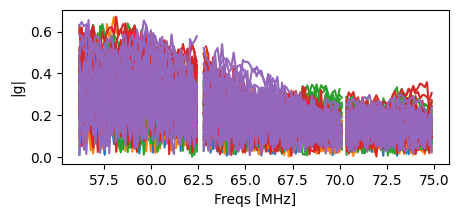

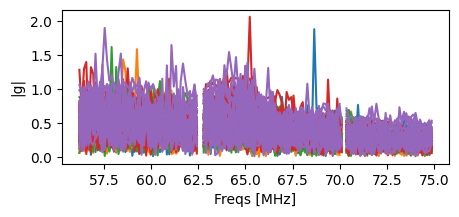

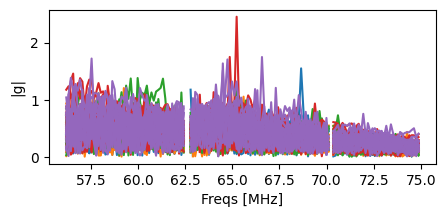

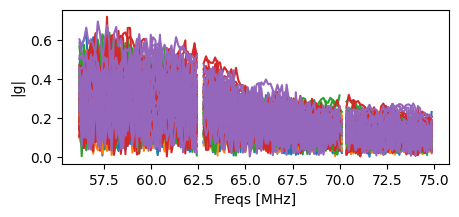

In [715]:
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_gleam)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_gleam_filter_notch)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_full_filter_notch)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_full)

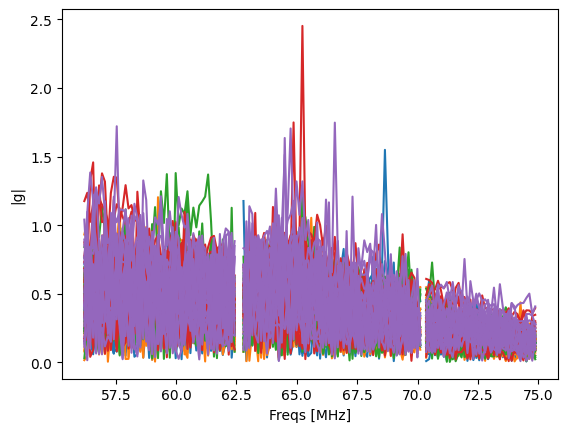

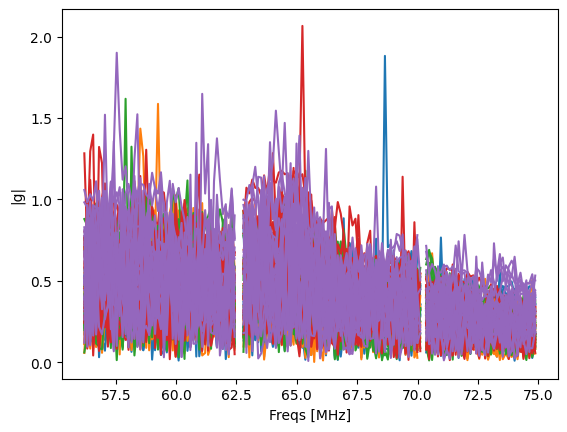

In [716]:
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_full_filter)
plt.figure()
produce_plots_colour_every_n_time(n=20, N=N-20, gains=gains_gleam_filter)

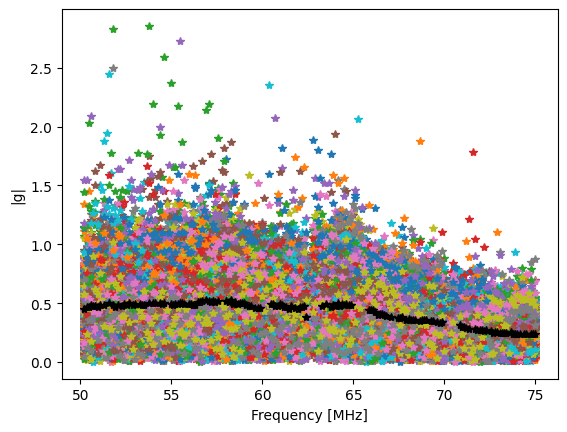

In [717]:
x=0
y=250
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.savefig("paper_figures/gains_notch.pdf")

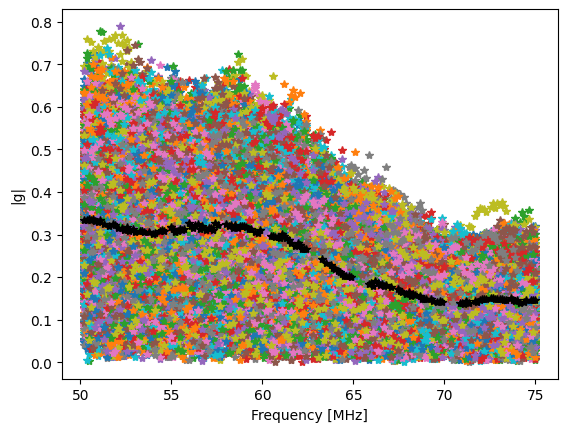

In [718]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.savefig("paper_figures/gains_no_filter_gleam.pdf")

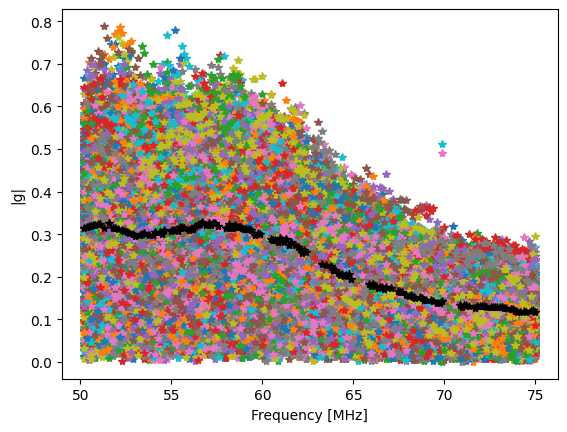

In [719]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.savefig("paper_figures/gains_no_filter_full.pdf")

## Avarage gain amplitude

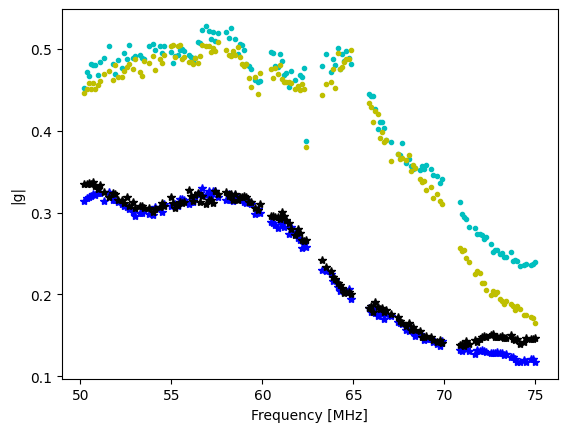

In [720]:
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0)),'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0)),'b*', label="GLEAM only") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k*', label="gleam, mainlobe ") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0)),'y.', label="Full, filtered ") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.savefig("paper_figures/gains_average_notch_filter_2.pdf")

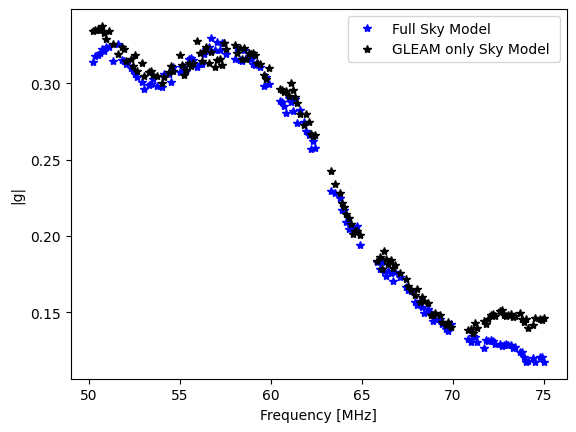

In [721]:

plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0)),'b*', label="Full Sky Model") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k*', label="GLEAM only Sky Model ") 

plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.legend()
plt.savefig("paper_figures/gains_average_no_filter.pdf")

## Delay Transform average gain

In [722]:
def fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=""):

    gains=np.abs(gains_raw)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>=0)
    tau_pos=tau[index]
    window=np.ones(gains.shape)
    for i in range(window.shape[0]):
        window[i,:]=windows.blackmanharris(len(freqs))
    
   
    gains_full_fitted=[]
    for t in range (gains.shape[0]):
        gains_time_no_nans=gains[t,:][~np.isnan(gains[t,:])]
        freq_no_nans=freqs[~np.isnan(gains[t,:])]
        coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        gains_fitted=[]
        for i in range (gains.shape[1]):
            if np.isnan(gains[t,i]):
                gains_fitted.append(poly(x_fit[i]))
            else:
                gains_fitted.append(gains[t,i])
        gains_fitted=np.array(gains_fitted)

        gains_full_fitted.append(gains_fitted)
    gains_full_fitted=np.array(gains_full_fitted)
    print(gains_full_fitted.shape)
    g0_delay=[]
    for i in range (gains_full_fitted.shape[0]-1):
        g1=np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted)))[i,:]
        g2=np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted)))[i+1,:]
        g0_delay.append(g1*np.conjugate(g2))
    g0_delay=np.array(g0_delay)
    
    g0_delay=np.mean(g0_delay,axis=0)[index]
    
    return np.mean(gains_full_fitted, axis=0), gains_full_fitted,np.abs(g0_delay), tau_pos





In [723]:
def produce_plots_delay(n,N):
    
    x,y=0,205
    gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full[n:N,x:y])
    gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam[n:N,x:y])
    gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam_filter[n:N,x:y])
    gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full_filter[n:N,x:y])
    gains_full_filter_ave_notch, g4, full_filter_notch_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full_filter_notch[n:N,x:y])
    gains_gleam_filter_ave_notch, g5, gleam_filter_notch_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam_filter_notch[n:N,x:y])
    
    
    
    # plt.plot(freqs[x:y], gains_full_ave,'k', label="full")
    # plt.plot(freqs[x:y], gains_gleam_ave, 'r', label="gleam")
    # plt.plot(freqs[x:y], gains_gleam_filter_ave, 'g', label="gleam filter")
    # plt.plot(freqs[x:y], gains_full_filter_ave, 'm', label="full filter")
    # plt.plot(freqs[x:y], gains_gleam_filter_ave_notch, 'c', label="notch gleam filter")
    # plt.plot(freqs[x:y], gains_full_filter_ave_notch, 'b', label="notch full filter")
    
    # plt.xlabel("Freq[MHz]")
    # plt.ylabel("$|g(\\nu)|$")
    # plt.legend()
    plt.figure()
    # print(tau_pos, gleam_delay)
    # plt.semilogy(tau_pos, full_delay,'k')
    # plt.semilogy(tau_pos, gleam_delay,'r')
    # plt.semilogy(tau_pos, gleam_filter_delay,'g')
    # plt.semilogy(tau_pos, full_filter_delay,'m')

    plt.semilogy(tau_pos, full_delay/np.max(full_delay),'b')
    plt.semilogy(tau_pos, gleam_delay/np.max(gleam_delay),'k')
    # plt.semilogy(tau_pos, gleam_filter_delay/np.max(gleam_filter_delay),'g')
    # plt.semilogy(tau_pos, full_filter_delay/np.max(full_filter_delay),'m')
    # plt.semilogy(tau_pos, full_filter_notch_delay/np.max(full_filter_notch_delay),'y')
    plt.semilogy(tau_pos, gleam_filter_notch_delay/np.max(gleam_filter_notch_delay),'c')
    plt.xlabel("Delay $\\tau$ [ns]")
    plt.ylabel("$|g(\\tau)|$")
    plt.xlim([0,600])
    plt.savefig("paper_figures/gains_delay_space_notch_filter_2.pdf")

(479, 205)
(479, 205)
(479, 205)
(479, 205)
(479, 205)
(479, 205)


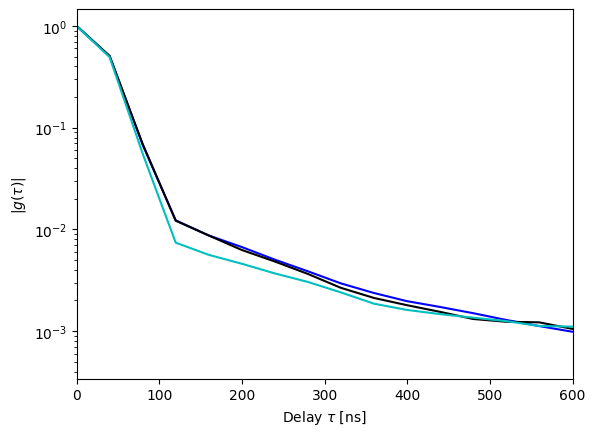

In [724]:
produce_plots_delay(n=0,N=1000)

## Chisq

In [674]:
N=90
chis_no_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_redcal_"+uvh5name[i][43:69]+".npy")

    chis_no_filer.append(g1)
chis_no_filer=np.array(chis_no_filer) 

In [677]:
chis_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_"+filter_name_2+"_redcal_"+uvh5name[i][43:69]+".npy")

    chis_filer.append(g1)
chis_filer=np.array(chis_filer) 

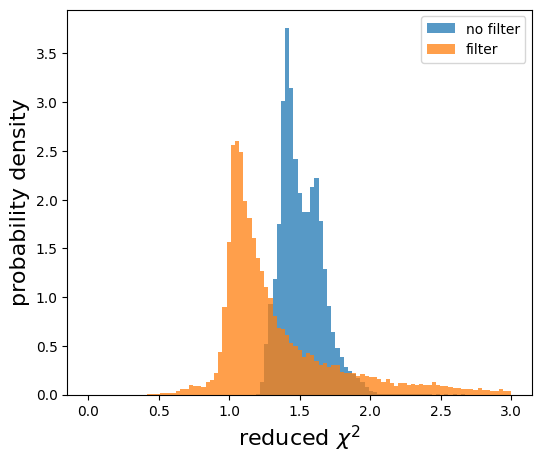

In [678]:
plt.figure(figsize=(6, 5))
plt.hist(np.abs(chis_no_filer.ravel()), bins=101, range=(0, 3), density=True, alpha=0.75,label="no filter")
plt.hist(np.abs(chis_filer.ravel())/0.15, bins=101, range=(0, 3), density=True, alpha=0.75,label="filter")
x = np.linspace(0.8, 1.2, 1000)
#plt.plot(x, stats.chi2.pdf(x * 2*dof, 2*dof) * 2*dof, c='k', ls='--', lw=2,label="$\chi_k^2$ (kx)/k ")
plt.xlabel(r'reduced $\chi^2$', fontsize=16)
plt.ylabel('probability density', fontsize=16)
plt.legend()